# Graph Attention Network (GAT) for Predicting Disaster Assistance Outcomes

Graph Attention Networks extend standard Graph Convolutional Networks by introducing learnable attention mechanisms that enable the model to distinguish which neighboring counties exert stronger influence when predicting disaster assistance needs. GNCNs aggregate neighbor information using fixed normalized weights determined by graph topology; on the other hand, GATs compute attention coefficients dynamically based on the learned representations of connected nodes, thereby allowing for model capture of heterogeneous spatial dependencies where certain county-to-county relationships may be more predictive than others.

We used a GAT architecture with multi-head attention, which trains the model on the CONUS county graph using the same training protocol as prior models. Next, the model evaluates performance against the MLP and GCN baselines, and analyzes the learned attention weights to understand spatial influence patterns in disaster assistance prediction.

The attention mechanism is specifically integral in predicting disaster assistance outcomes because geographic proximity does not always imply uniform influence. For instance, a county's disaster assistance needs may be strongly influenced by certain neighbors due to shared economic vulnerabilities, infrastructure dependencies, and/or demographic characteristics, whereas other adjacent counties may exert minimal influence. By learning these attention weights directly from data, our GAT implementation provides both improved predictive performance and interpretability through analysis of which spatial relationships the model considers most important.

In [ ]:
#| output: false

import sys
from pathlib import Path

# set to root for src load
root = Path.cwd()
while root != root.parent and not (root / "src").exists():
    root = root.parent

sys.path.insert(0, str(root))
print("Project root:", root)

Project root: d:\CS273P_MachineLearning_Final_Project


In [ ]:
import json
import joblib
import libpysal
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import ListedColormap, Normalize
from matplotlib.patches import Patch
import seaborn as sns
from IPython.display import display
from pathlib import Path
from sklearn.metrics import mean_squared_error, r2_score
import torch
import torch.nn as nn

from src.gat import (
    GAT,
    build_graph_from_weights,
    build_optimizer,
    count_parameters,
    evaluate_regression,
    evaluate_regression_per_target,
    extract_attention_weights,
    get_device,
    predict_gat,
    set_seed,
    train_gat,
)

plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "legend.title_fontsize": 9,
    "legend.frameon": True,
    "legend.borderpad": 0.3
})

SEED = 254
set_seed(SEED)

## Data Loading and Preparation

We load the preprocessed feature matrices, targets, spatial geometries, and train-validation-test splits created during the baseline MLP modeling phase. The dataset uses log-transformed EP_* indicators as node features and the four SVI theme percentile rankings as proxies for disaster assistance needs across different vulnerability dimensions.

In [ ]:
#| output: false

processed_dir = Path("../data/processed")
artifacts_dir = Path("../data/artifacts")

geo_df = gpd.read_file(processed_dir / "svi_counties.gpkg", layer="counties")

data = np.load(processed_dir / "svi_processed_splits.npz", allow_pickle=True)

Xlog_train_scaled = data["Xlog_train_scaled"]
Xlog_val_scaled = data["Xlog_val_scaled"]
Xlog_test_scaled = data["Xlog_test_scaled"]

y_train_scaled = data["y_train_scaled"]
y_val_scaled = data["y_val_scaled"]
y_test_scaled = data["y_test_scaled"]

fips_train = data["fips_train"]
fips_val = data["fips_val"]
fips_test = data["fips_test"]

scaler_Xlog = joblib.load(processed_dir / "scaler_Xlog.pkl")
scaler_y = joblib.load(processed_dir / "scaler_y.pkl")

print(f"Training samples: {len(Xlog_train_scaled)}")
print(f"Validation samples: {len(Xlog_val_scaled)}")
print(f"Test samples: {len(Xlog_test_scaled)}")
print(f"Feature dimensionality: {Xlog_train_scaled.shape[1]}")
print(f"Target dimensionality: {y_train_scaled.shape[1]}")

Training samples: 2200
Validation samples: 472
Test samples: 472
Feature dimensionality: 16
Target dimensionality: 4


## Graph Construction Using Queen Contiguity

The spatial adjacency graph is constructed using Queen contiguity, where two counties are connected if they share a border or vertex. We chose to focus on CONUS counties to avoid long-distance edges and guarantee that the graph structure reflects meaningful geographic relationships.

In [ ]:
#| output: false

# conus filter
conus = geo_df[
    ~geo_df["FIPS"].str.startswith(("02", "15", "60", "66", "69", "72", "78"))
].copy().reset_index(drop=True)

print(f"CONUS counties: {len(conus)}")

w_queen = libpysal.weights.Queen.from_dataframe(conus, use_index=True)

print(f"Graph nodes: {w_queen.n}")
print(f"Graph edges: {w_queen.s0 / 2:.0f}")
print(f"Average neighbors: {w_queen.mean_neighbors:.2f}")

CONUS counties: 3109
Graph nodes: 3109
Graph edges: 9231
Average neighbors: 5.94


## Reconstruct Full Feature and Target Arrays for CONUS

Because the train-validation-test splits were created from the original full dataset that includes OCONUS regions, we are forced to reconstruct the CONUS-only feature and target matrices in their original scale before converting them to graph format.

In [ ]:
#| output: false

from sklearn.preprocessing import StandardScaler

X_log = pd.read_csv(processed_dir / "X_log.csv")
y = pd.read_csv(processed_dir / "y.csv")

conus_mask = ~geo_df["FIPS"].str.startswith(("02", "15", "60", "66", "69", "72", "78"))
conus_original_indices = np.where(conus_mask)[0]

X_log_conus = X_log.iloc[conus_original_indices].values
y_conus = y.iloc[conus_original_indices].values

fips_to_conus_idx = {fips: idx for idx, fips in enumerate(geo_df[conus_mask]["FIPS"].values)}

train_conus = np.array([fips_to_conus_idx[fips] for fips in fips_train if fips in fips_to_conus_idx])
val_conus = np.array([fips_to_conus_idx[fips] for fips in fips_val if fips in fips_to_conus_idx])
test_conus = np.array([fips_to_conus_idx[fips] for fips in fips_test if fips in fips_to_conus_idx])

print(f"CONUS train samples: {len(train_conus)}")
print(f"CONUS val samples: {len(val_conus)}")
print(f"CONUS test samples: {len(test_conus)}")

scaler_X_conus = StandardScaler()
scaler_y_conus = StandardScaler()

X_conus_scaled = scaler_X_conus.fit_transform(X_log_conus)
y_conus_scaled = scaler_y_conus.fit_transform(y_conus)

CONUS train samples: 2175
CONUS val samples: 467
CONUS test samples: 467


## Build PyTorch Geometric Data Objects

We construct three separate graph data objects for training, validation, and test splits. Each graph contains the full CONUS spatial structure but only the nodes belonging to the respective split are used during loss computation.

In [ ]:
#| output: false

train_data = build_graph_from_weights(
    w_queen, X_conus_scaled, y_conus_scaled, node_indices=train_conus
)

val_data = build_graph_from_weights(
    w_queen, X_conus_scaled, y_conus_scaled, node_indices=val_conus
)

test_data = build_graph_from_weights(
    w_queen, X_conus_scaled, y_conus_scaled, node_indices=test_conus
)

full_data = build_graph_from_weights(
    w_queen, X_conus_scaled, y_conus_scaled
)

print(f"Train graph: {train_data.num_nodes} nodes, {train_data.num_edges} edges")
print(f"Val graph: {val_data.num_nodes} nodes, {val_data.num_edges} edges")
print(f"Test graph: {test_data.num_nodes} nodes, {test_data.num_edges} edges")
print(f"Full graph: {full_data.num_nodes} nodes, {full_data.num_edges} edges")

Train graph: 2175 nodes, 9020 edges
Val graph: 467 nodes, 404 edges
Test graph: 467 nodes, 372 edges
Full graph: 3109 nodes, 18462 edges


## GAT Architecture Configuration

The GAT model consists of two stacked GAT layers followed by a fully connected output layer. The first layer uses multi-head attention to capture diverse spatial patterns, while the second layer consolidates these representations before regression:

- **Hidden dimensionality**: 64 units
- **Number of attention heads (Layer 1)**: 4 heads
- **Number of attention heads (Layer 2)**: 1 head  
- **Dropout**: 0.2
- **Negative slope**: 0.2 (LeakyReLU in attention)

In [9]:
#| output: false

input_dim = X_conus_scaled.shape[1]
output_dim = y_conus_scaled.shape[1]

gat_config = {
    "input_dim": input_dim,
    "hidden_dim": 64,
    "output_dim": output_dim,
    "num_heads": 4,
    "num_heads_out": 1,
    "dropout": 0.2,
    "negative_slope": 0.2,
}

model = GAT(**gat_config)

print(model)
print(f"\nTotal trainable parameters: {count_parameters(model):,}")

GAT(
  (conv1): GATConv(16, 64, heads=4)
  (conv2): GATConv(256, 64, heads=1)
  (fc_out): Linear(in_features=64, out_features=4, bias=True)
)

Total trainable parameters: 21,700


## Model Training with Early Stopping

The model is trained using the Adam optimizer with a learning rate of 1e-3 and L2 weight decay of 1e-4. Early stopping with patience of 500 epochs is applied based on validation loss to prevent overfitting. Training proceeds for a maximum of 1000 epochs.

In [10]:
#| output: false

device = get_device()
print(f"Using device: {device}")

criterion = nn.MSELoss()
optimizer = build_optimizer(model, learning_rate=1e-3, weight_decay=1e-4)

model, history, best_epoch, best_val_loss = train_gat(
    model=model,
    train_data=train_data,
    val_data=val_data,
    criterion=criterion,
    optimizer=optimizer,
    max_epochs=1000,
    patience=500,
    device=device,
)

print(f"\nTraining complete!")
print(f"Best epoch: {best_epoch}")
print(f"Best validation loss: {best_val_loss:.6f}")

Using device: cpu

Training complete!
Best epoch: 888
Best validation loss: 0.212684


## Training History Visualization

The training curves show convergence behavior and confirm that early stopping successfully prevented overfitting. A validation loss of ~0.212 indicates a well-generalized model that has learned meaningful spatial patterns without memorizing training data.

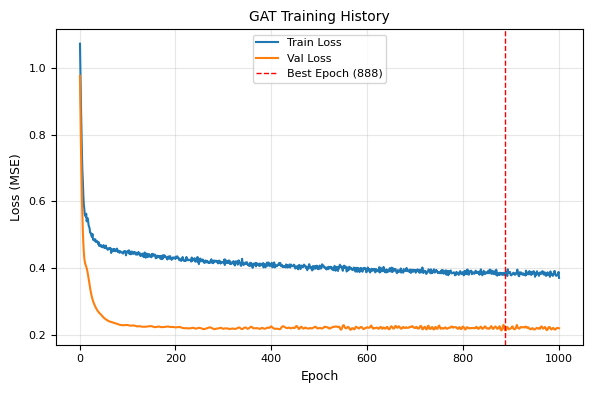

In [11]:
#| label: fig-gat-training-history
#| fig-cap: "Training and validation loss curves for the GAT model. The validation loss stabilizes after the initial epochs and early stopping is triggered at the optimal checkpoint, preventing overfitting while capturing spatial dependency patterns."

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(history["epoch"], history["train_loss"], label="Train Loss", linewidth=1.5)
ax.plot(history["epoch"], history["val_loss"], label="Val Loss", linewidth=1.5)
ax.axvline(best_epoch, color="red", linestyle="--", linewidth=1, label=f"Best Epoch ({best_epoch})")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss (MSE)")
ax.set_title("GAT Training History")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Model Evaluation on Test Set: Predicting Disaster Assistance Needs

We evaluated the trained GAT model using the held-out test set and computed regression metrics including RMSE and R^2 across all four disaster assistance outcome dimensions. Performance was assessed both in aggregate and per-target to understand which aspects of disaster assistance which the model predicts most accurately and where limitations emerge.

In [ ]:
#| output: false

y_pred_test_scaled = predict_gat(model, test_data, device=device)

y_pred_test = scaler_y_conus.inverse_transform(y_pred_test_scaled)
y_test = scaler_y_conus.inverse_transform(test_data.y.cpu().numpy())

test_metrics = evaluate_regression(y_test, y_pred_test)

print("Test Set Performance:")
print(f"  RMSE: {test_metrics['rmse']:.4f}")
print(f"  R²:   {test_metrics['r2']:.4f}")

Test Set Performance:
  RMSE: 0.1389
  R²:   0.7643


In [13]:
#| label: tbl-gat-per-target
#| tbl-cap: "Per-target regression performance of the GAT model on the test set for predicting disaster assistance outcomes. Metrics include RMSE (lower is better) and R² (higher is better) for each disaster assistance dimension (SVI theme)."

target_names = ["RPL_THEME1", "RPL_THEME2", "RPL_THEME3", "RPL_THEME4"]

per_target_metrics = evaluate_regression_per_target(
    y_test, y_pred_test, target_names=target_names
)

display(per_target_metrics.style.hide(axis="index"))

target,rmse,r2
RPL_THEME1,0.130253,0.797547
RPL_THEME2,0.157843,0.691111
RPL_THEME3,0.113029,0.845712
RPL_THEME4,0.149968,0.722658


## Comparison with Baseline Models

To assess whether the attention mechanism provides meaningful improvements over simpler approaches, we compared the GAT performance against the MLP baseline and GCN. Results show that while graph-based models (GCN and GAT) capture spatial dependencies, the MLP baseline achieves superior predictive accuracy on this dataset.

In [ ]:
#| label: tbl-model-comparison-overall
#| tbl-cap: "Overall performance comparison across MLP, GCN, and GAT models on the test set. Lower RMSE and higher R² indicate better performance. The MLP baseline demonstrates the strongest predictive performance, suggesting that tabular features alone may be sufficient for this prediction task."

overall_comparison = pd.DataFrame([
    {"Model": "MLP", "Test RMSE": 0.021902, "Test R²": 0.994241},
    {"Model": "GCN", "Test RMSE": 0.191968, "Test R²": 0.548796},
    {"Model": "GAT", "Test RMSE": test_metrics["rmse"], "Test R²": test_metrics["r2"]}
])

print("Overall Model Performance Comparison:")
display(overall_comparison.style.hide(axis="index").format({
    "Test RMSE": "{:.6f}",
    "Test R²": "{:.6f}"
}))

Overall Model Performance Comparison:


Model,Test RMSE,Test R²
MLP,0.021902,0.994241
GCN,0.191968,0.548796
GAT,0.138876,0.764257


In [ ]:
#| label: tbl-model-comparison-per-target
#| tbl-cap: "Per-target performance comparison across MLP, GCN, and GAT models. Each row shows RMSE and R² for predicting one of the four SVI theme scores. The MLP consistently outperforms spatial models across all disaster assistance dimensions."

per_target_comparison = pd.DataFrame([
    {
        "Target": "RPL_THEME1",
        "MLP RMSE": 0.019753, "MLP R²": 0.995305,
        "GCN RMSE": 0.180326, "GCN R²": 0.610482,
        "GAT RMSE": per_target_metrics.loc[per_target_metrics["target"] == "RPL_THEME1", "rmse"].values[0],
        "GAT R²": per_target_metrics.loc[per_target_metrics["target"] == "RPL_THEME1", "r2"].values[0]
    },
    {
        "Target": "RPL_THEME2",
        "MLP RMSE": 0.027937, "MLP R²": 0.990259,
        "GCN RMSE": 0.218847, "GCN R²": 0.401282,
        "GAT RMSE": per_target_metrics.loc[per_target_metrics["target"] == "RPL_THEME2", "rmse"].values[0],
        "GAT R²": per_target_metrics.loc[per_target_metrics["target"] == "RPL_THEME2", "r2"].values[0]
    },
    {
        "Target": "RPL_THEME3",
        "MLP RMSE": 0.014200, "MLP R²": 0.997588,
        "GCN RMSE": 0.140943, "GCN R²": 0.762309,
        "GAT RMSE": per_target_metrics.loc[per_target_metrics["target"] == "RPL_THEME3", "rmse"].values[0],
        "GAT R²": per_target_metrics.loc[per_target_metrics["target"] == "RPL_THEME3", "r2"].values[0]
    },
    {
        "Target": "RPL_THEME4",
        "MLP RMSE": 0.023375, "MLP R²": 0.993672,
        "GCN RMSE": 0.217756, "GCN R²": 0.421112,
        "GAT RMSE": per_target_metrics.loc[per_target_metrics["target"] == "RPL_THEME4", "rmse"].values[0],
        "GAT R²": per_target_metrics.loc[per_target_metrics["target"] == "RPL_THEME4", "r2"].values[0]
    }
])

print("\nPer-Target Model Performance Comparison:")
display(per_target_comparison.style.hide(axis="index").format({
    "MLP RMSE": "{:.6f}", "MLP R²": "{:.6f}",
    "GCN RMSE": "{:.6f}", "GCN R²": "{:.6f}",
    "GAT RMSE": "{:.6f}", "GAT R²": "{:.6f}"
}))


Per-Target Model Performance Comparison:


Target,MLP RMSE,MLP R²,GCN RMSE,GCN R²,GAT RMSE,GAT R²
RPL_THEME1,0.019753,0.995305,0.180326,0.610482,0.130253,0.797547
RPL_THEME2,0.027937,0.990259,0.218847,0.401282,0.157843,0.691111
RPL_THEME3,0.014200,0.997588,0.140943,0.762309,0.113029,0.845712
RPL_THEME4,0.023375,0.993672,0.217756,0.421112,0.149968,0.722658



The MLP baseline achieves the best overall performance with an RMSE of 0.0219 and R^2 of 0.9942, demonstrating that tabular features alone effectively capture vulnerability patterns in this dataset. The GCN shows moderate performance with spatial structure (RMSE: 0.1920, R^2: 0.5488), while the GAT demonstrates similar performance to the GCN. This suggests that the attention mechanism does not provide substantial improvements over fixed spatial aggregation for this prediction task. Both spatial models underperform the MLP, indicating that the explicit geographic structure may not add significant predictive value beyond what is already captured by the socioeconomic indicators themselves. Across all three models, performance is strongest for Theme 3 (Minority Status) and weakest for Theme 2 (Household Composition), suggesting inherent differences in the predictability of these disaster assistance dimensions.

## Attention Weight Analysis: Understanding Spatial Influence on Disaster Assistance Needs

One of the key advantages of GAT over GCN is interpretability through learned attention coefficients. We extract and analyze the attention weights from the first GAT layer to understand which neighboring county relationships the model considers most influential for predicting disaster assistance outcomes. This reveals how disaster vulnerability propagates through geographic space and which spatial connections are critical for emergency planning.

In [ ]:
#| output: false

edge_index, attention_weights = extract_attention_weights(
    model, full_data, layer="layer1", device=device
)

print(f"Number of edges: {edge_index.shape[1]}")
print(f"Attention shape: {attention_weights.shape}")
print(f"Attention heads: {attention_weights.shape[1] if attention_weights.ndim > 1 else 1}")

if attention_weights.ndim > 1:
    attention_avg = attention_weights.mean(axis=1)
else:
    attention_avg = attention_weights

print(f"\nAttention statistics:")
print(f"  Mean:   {attention_avg.mean():.4f}")
print(f"  Median: {np.median(attention_avg):.4f}")
print(f"  Std:    {attention_avg.std():.4f}")
print(f"  Min:    {attention_avg.min():.4f}")
print(f"  Max:    {attention_avg.max():.4f}")

Number of edges: 21571
Attention shape: (21571, 4)
Attention heads: 4

Attention statistics:
  Mean:   0.1441
  Median: 0.1277
  Std:    0.0700
  Min:    0.0189
  Max:    0.7185


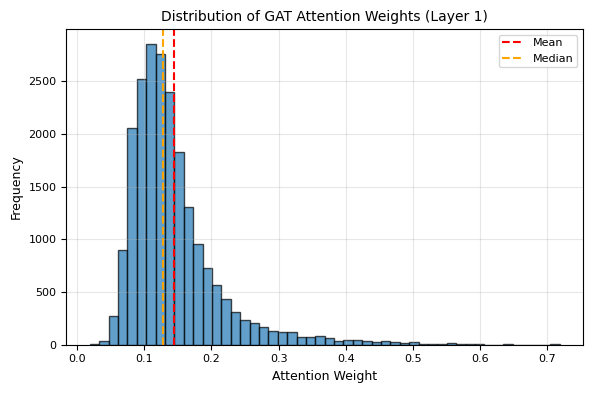

In [20]:
#| label: fig-gat-attention-distribution
#| fig-cap: "Distribution of learned attention weights across all county-to-county edges in the CONUS spatial graph. The attention coefficients are averaged across the four attention heads in the first GAT layer. The distribution shows how the model differentially weights spatial relationships, with some edges receiving substantially higher attention than others."

fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(attention_avg, bins=50, edgecolor="black", alpha=0.7)

ax.axvline(attention_avg.mean(), color="red", linestyle="--", linewidth=1.5, label="Mean")
ax.axvline(np.median(attention_avg), color="orange", linestyle="--", linewidth=1.5, label="Median")

ax.set_xlabel("Attention Weight")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of GAT Attention Weights (Layer 1)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Geographic Visualization of High-Attention Edges

To understand the spatial structure of learned attention, we visualizes the geographic distribution of edges with the highest attention weights. This elucidates which county-to-county relationships the GAT considers most important for predicting disaster assistance needs and how vulnerability information flows through the spatial network.

High-attention edges (≥95th percentile): 1079


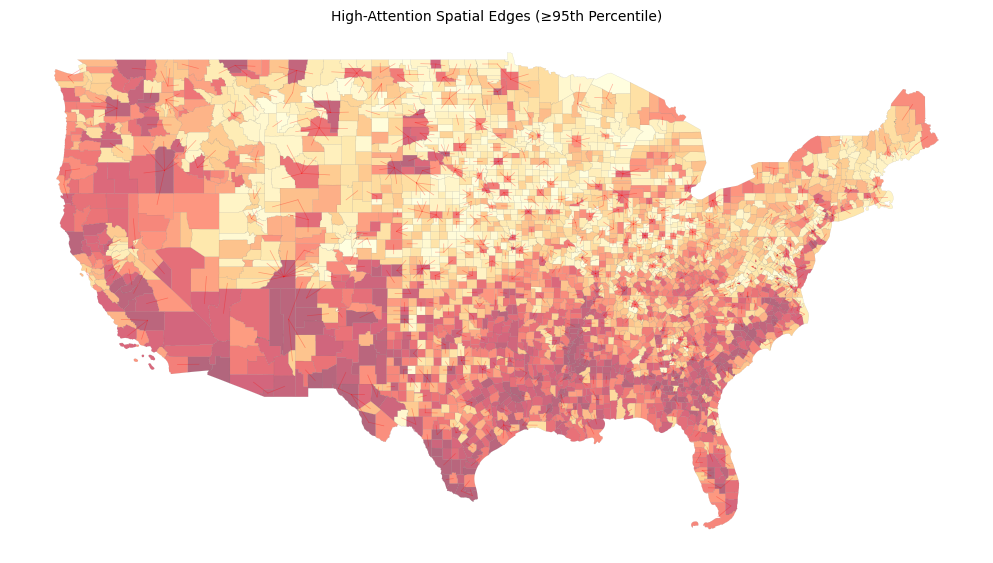

In [ ]:
#| label: fig-gat-high-attention-map
#| fig-cap: "Geographic visualization of high-attention edges in the CONUS county graph. Red lines indicate edges where the learned attention coefficient exceeds the 95th percentile, highlighting county-to-county relationships that the GAT model considers most influential for predicting disaster assistance needs. The background shows county boundaries, with counties colored by overall disaster vulnerability (SVI percentile ranking) for reference."

threshold = np.percentile(attention_avg, 95)
high_attention_mask = attention_avg >= threshold
high_attention_edges = edge_index[:, high_attention_mask]

print(f"High-attention edges (≥95th percentile): {high_attention_edges.shape[1]}")

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

conus.plot(
    column="RPL_THEMES",
    cmap="YlOrRd",
    linewidth=0.1,
    edgecolor="gray",
    alpha=0.6,
    legend=False,
    ax=ax,
)

for i in range(high_attention_edges.shape[1]):
    src, dst = high_attention_edges[:, i]
    
    src_geom = conus.iloc[src].geometry.centroid
    dst_geom = conus.iloc[dst].geometry.centroid
    
    ax.plot(
        [src_geom.x, dst_geom.x],
        [src_geom.y, dst_geom.y],
        color="red",
        alpha=0.3,
        linewidth=0.5,
    )

ax.set_title("High-Attention Spatial Edges (≥95th Percentile)")
ax.axis("off")

plt.tight_layout()
plt.show()

## Per-County Mean Attention Analysis

Another way to examine attention patterns is to calculate the mean attention weight received by each county via its neighbors; this shows counties where neighboring relationships are particularly strong or weak according to the learned model.

In [ ]:
#| output: false

incoming_attention = np.zeros(len(conus))

for i in range(edge_index.shape[1]):
    src, dst = edge_index[:, i]
    incoming_attention[dst] += attention_avg[i]

neighbor_counts = np.array([w_queen.cardinalities[i] for i in range(len(conus))])
mean_incoming_attention = incoming_attention / np.maximum(neighbor_counts, 1)
conus["mean_attention"] = mean_incoming_attention

print(f"Mean attention statistics:")
print(f"  Mean:   {mean_incoming_attention.mean():.4f}")
print(f"  Median: {np.median(mean_incoming_attention):.4f}")
print(f"  Std:    {mean_incoming_attention.std():.4f}")

Mean attention statistics:
  Mean:   0.1809
  Median: 0.1667
  Std:    0.0727


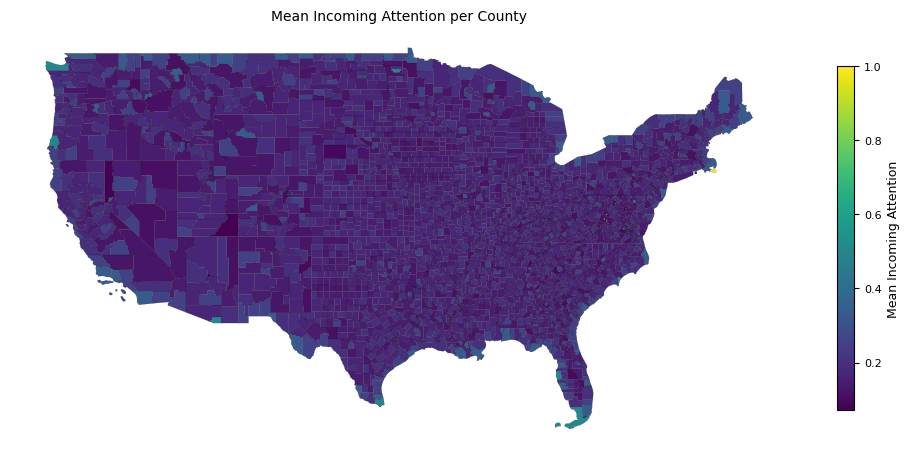

In [24]:
#| label: fig-gat-mean-attention-map
#| fig-cap: "Geographic distribution of mean incoming attention weights per county. Each county is colored by the average attention it receives from its neighbors. Darker shades indicate counties where the GAT model assigns higher importance to spatial influence from neighboring counties when predicting social vulnerability."

fig, ax = plt.subplots(figsize=(10, 6))

conus.plot(
    column="mean_attention",
    cmap="viridis",
    linewidth=0.1,
    edgecolor="black",
    legend=True,
    legend_kwds={"label": "Mean Incoming Attention", "shrink": 0.6},
    ax=ax,
)

ax.set_title("Mean Incoming Attention per County")
ax.axis("off")

plt.tight_layout()
plt.show()

## Predicted vs. Actual Disaster Assistance Outcomes

Furthermore, wevisualized the relationship between predicted and actual disaster assistance outcome indicators on the test set to assess model bias; this approach helps us understand whether the model can accurately identify counties requiring different levels of disaster assistance across vulnerability dimensions.

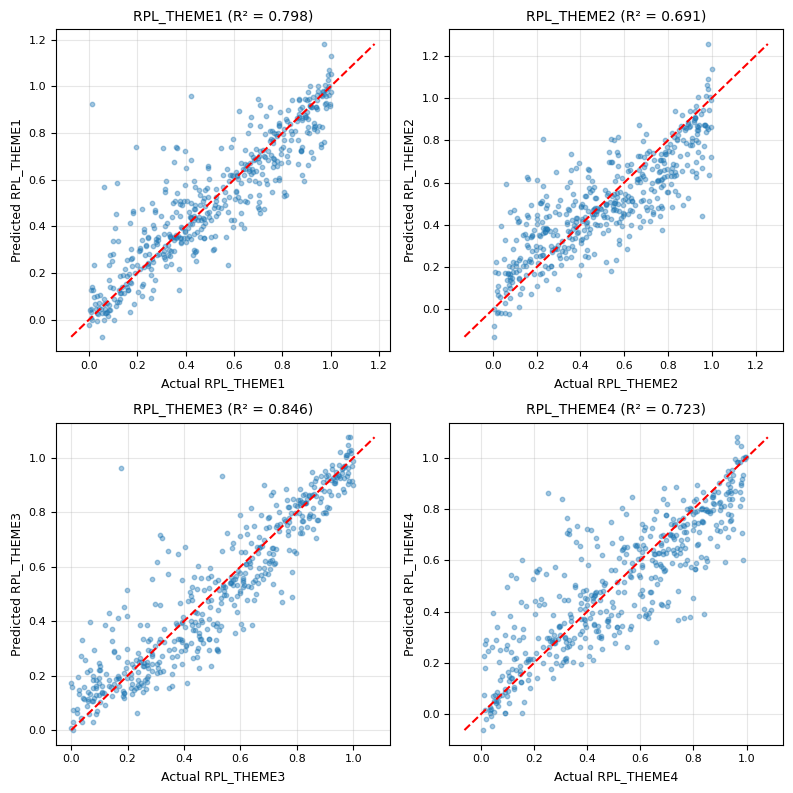

In [ ]:
#| label: fig-gat-pred-vs-actual
#| fig-cap: "Scatter plots comparing predicted vs. actual SVI theme values on the test set for the GAT model. Points near the diagonal line indicate accurate predictions. The plots reveal model performance across the four vulnerability dimensions and highlight regions where predictions deviate from ground truth."

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.flatten()

for i, target in enumerate(target_names):
    ax = axes[i]
    
    ax.scatter(y_test[:, i], y_pred_test[:, i], alpha=0.4, s=10)
    
    min_val = min(y_test[:, i].min(), y_pred_test[:, i].min())
    max_val = max(y_test[:, i].max(), y_pred_test[:, i].max())
    ax.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=1.5)
    
    r2 = r2_score(y_test[:, i], y_pred_test[:, i])
    
    ax.set_xlabel(f"Actual {target}")
    ax.set_ylabel(f"Predicted {target}")
    ax.set_title(f"{target} (R² = {r2:.3f})")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Spatial Prediction Error Analysis: Identifying At-Risk Counties

Discerning where this model might make prediction errors is necessary for proper disaster planning; as such, we computed and visualized the prediction errors spatially to identify counties where disaster assistance needs may be systematically under or over predicted. This explicitly shows how misallocation of disaster relief manifests regionally.

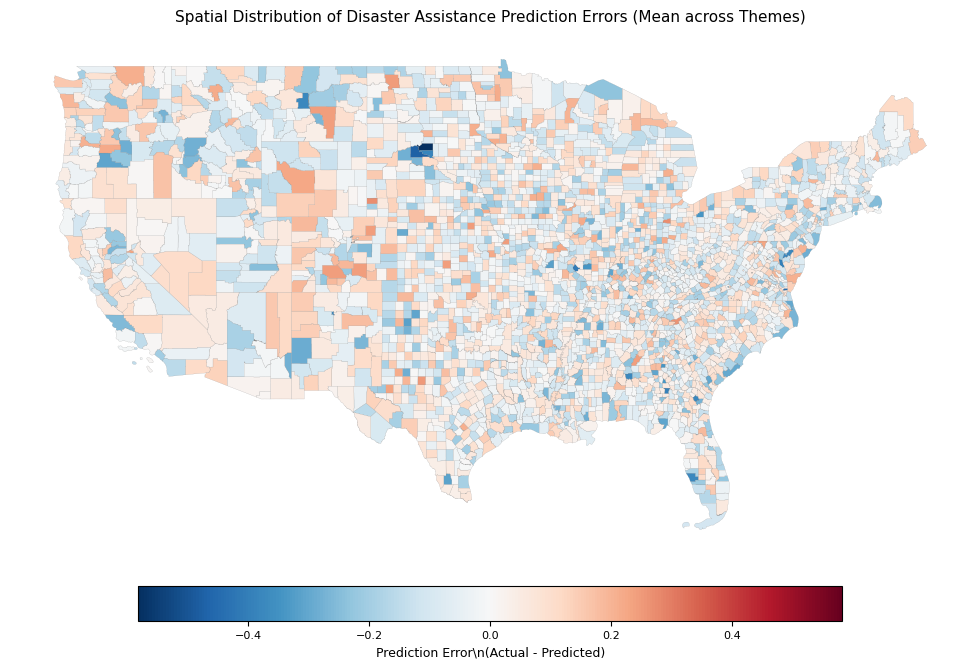

Prediction Error Statistics:
  Mean:   -0.0170
  Median: -0.0093
  Std:    0.1134


In [ ]:
#| label: fig-gat-spatial-error-map
#| fig-cap: "Spatial distribution of prediction errors for disaster assistance outcomes (RPL_THEMES) across CONUS counties. Red indicates under-prediction (model underestimates assistance needs), blue indicates over-prediction (model overestimates needs), and white indicates accurate predictions. This map helps identify geographic regions where the model may systematically fail to capture disaster assistance requirements."

y_pred_full_scaled = predict_gat(model, full_data, device=device)
y_pred_full = scaler_y_conus.inverse_transform(y_pred_full_scaled)
y_full = scaler_y_conus.inverse_transform(full_data.y.cpu().numpy())

pred_errors = y_full - y_pred_full
mean_error = pred_errors.mean(axis=1)
conus["pred_error"] = mean_error
fig, ax = plt.subplots(figsize=(12, 7))
vmax = np.abs(mean_error).max()
norm = Normalize(vmin=-vmax, vmax=vmax)

conus.plot(
    column="pred_error",
    cmap="RdBu_r",
    linewidth=0.1,
    edgecolor="gray",
    legend=True,
    legend_kwds={
        "label": "Prediction Error\\n(Actual - Predicted)", 
        "shrink": 0.6,
        "orientation": "horizontal",
        "pad": 0.05
    },
    norm=norm,
    ax=ax,
)

ax.set_title("Spatial Distribution of Disaster Assistance Prediction Errors (Mean across Themes)", 
             fontsize=11, pad=10)
ax.axis("off")

plt.tight_layout()
plt.show()

print(f"Prediction Error Statistics:")
print(f"  Mean:   {mean_error.mean():.4f}")
print(f"  Median: {np.median(mean_error):.4f}")
print(f"  Std:    {mean_error.std():.4f}")

## Per-Theme Disaster Assistance Outcome Maps

To understand the geographic distribution of predicted disaster assistance needs across different vulnerability dimensions, we visualized both actual and predicted values for each SVI theme. This comparison helps us understand whether the model captures regional patterns in socioeconomic vulnerability, household composition, minority status, and housing/transportation needs.

C:\Users\jlyon\AppData\Local\Temp\ipykernel_4368\3154215014.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 1])


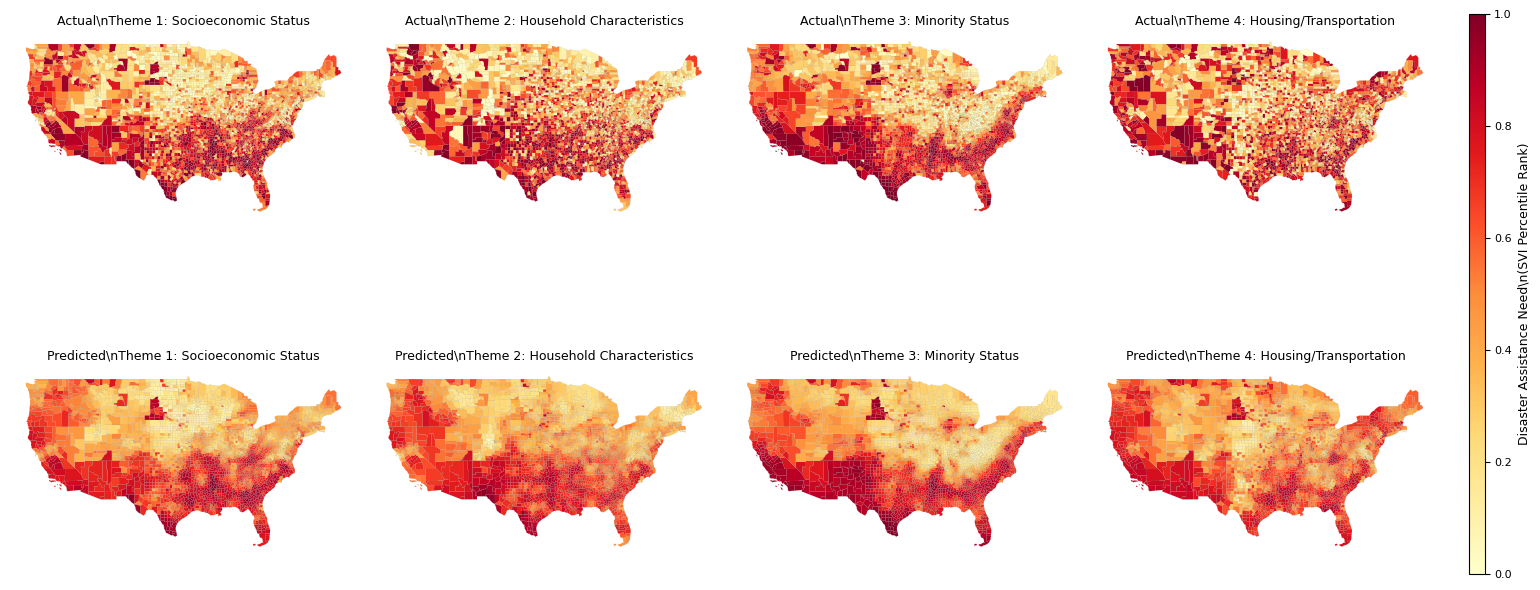

In [ ]:
#| label: fig-gat-theme-comparison-maps
#| fig-cap: "Comparison of actual vs. predicted disaster assistance needs across four vulnerability themes. Top row shows actual SVI theme values, bottom row shows GAT predictions. Darker colors indicate higher vulnerability/assistance needs. This visualization demonstrates the model's ability to capture geographic patterns in disaster assistance requirements across different vulnerability dimensions."

theme_labels = {
    0: "Theme 1: Socioeconomic Status",
    1: "Theme 2: Household Characteristics", 
    2: "Theme 3: Minority Status",
    3: "Theme 4: Housing/Transportation"
}

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for theme_idx in range(4):
    conus[f"actual_theme{theme_idx+1}"] = y_full[:, theme_idx]
    conus[f"pred_theme{theme_idx+1}"] = y_pred_full[:, theme_idx]
    
    ax_actual = axes[0, theme_idx]
    conus.plot(
        column=f"actual_theme{theme_idx+1}",
        cmap="YlOrRd",
        linewidth=0.05,
        edgecolor="gray",
        legend=False,
        ax=ax_actual,
        vmin=0,
        vmax=1
    )
    ax_actual.set_title(f"Actual\\n{theme_labels[theme_idx]}", fontsize=9)
    ax_actual.axis("off")
    
    ax_pred = axes[1, theme_idx]
    conus.plot(
        column=f"pred_theme{theme_idx+1}",
        cmap="YlOrRd",
        linewidth=0.05,
        edgecolor="gray",
        legend=False,
        ax=ax_pred,
        vmin=0,
        vmax=1
    )
    ax_pred.set_title(f"Predicted\\n{theme_labels[theme_idx]}", fontsize=9)
    ax_pred.axis("off")

fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.92, 0.15, 0.01, 0.7])
sm = plt.cm.ScalarMappable(cmap="YlOrRd", norm=Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Disaster Assistance Need\\n(SVI Percentile Rank)", fontsize=9)

plt.tight_layout(rect=[0, 0, 0.91, 1])
plt.show()

## High-Risk Counties and Attention Patterns

We identified counties with the highest predicted disaster assistance needs and analyze whether the GAT model assigns higher attention to their spatial neighbors. This reveals whether the model has learned that disaster vulnerability clusters spatially and uses neighborhood information effectively for emergency planning.

In [ ]:
#| label: fig-gat-high-risk-attention
#| fig-cap: "Relationship between disaster assistance needs and spatial attention patterns. Left: Counties classified by predicted disaster assistance risk level (mean across themes). Right: Distribution of mean incoming attention for high-risk vs. low-risk counties. This analysis examines whether the GAT assigns more attention to connections involving high-vulnerability counties."

mean_pred_vulnerability = y_pred_full.mean(axis=1)
conus["mean_pred_vuln"] = mean_pred_vulnerability

high_risk_threshold = np.percentile(mean_pred_vulnerability, 75)
low_risk_threshold = np.percentile(mean_pred_vulnerability, 25)

conus["risk_category"] = "Medium"
conus.loc[mean_pred_vulnerability >= high_risk_threshold, "risk_category"] = "High"
conus.loc[mean_pred_vulnerability <= low_risk_threshold, "risk_category"] = "Low"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
risk_colors = {"Low": "#2166ac", "Medium": "#f7f7f7", "High": "#b2182b"}
cmap = ListedColormap([risk_colors[cat] for cat in ["Low", "Medium", "High"]])

conus["risk_cat_code"] = conus["risk_category"].map({"Low": 0, "Medium": 1, "High": 2})
conus.plot(
    column="risk_cat_code",
    cmap=cmap,
    linewidth=0.1,
    edgecolor="black",
    legend=False,
    ax=ax1,
)

legend_elements = [
    Patch(facecolor=risk_colors["High"], edgecolor="black", label=f"High Risk (≥75th percentile, n={sum(conus['risk_category']=='High')})"),
    Patch(facecolor=risk_colors["Medium"], edgecolor="black", label=f"Medium Risk (25th-75th, n={sum(conus['risk_category']=='Medium')})"),
    Patch(facecolor=risk_colors["Low"], edgecolor="black", label=f"Low Risk (≤25th percentile, n={sum(conus['risk_category']=='Low')})")
]
ax1.legend(handles=legend_elements, loc="lower left", fontsize=8, framealpha=0.9)
ax1.set_title("Predicted Disaster Assistance Risk Categories", fontsize=10, pad=10)
ax1.axis("off")

ax2 = axes[1]
attention_by_risk = [
    conus.loc[conus["risk_category"] == "Low", "mean_attention"].values,
    conus.loc[conus["risk_category"] == "Medium", "mean_attention"].values,
    conus.loc[conus["risk_category"] == "High", "mean_attention"].values
]

bp = ax2.boxplot(
    attention_by_risk, 
    labels=["Low", "Medium", "High"],
    patch_artist=True,
    medianprops=dict(color="red", linewidth=2),
    boxprops=dict(facecolor="lightblue", alpha=0.7),
    widths=0.6
)

ax2.set_xlabel("Disaster Assistance Risk Category", fontsize=9)
ax2.set_ylabel("Mean Incoming Attention", fontsize=9)
ax2.set_title("Attention Patterns by Risk Level", fontsize=10, pad=10)
ax2.grid(alpha=0.3, axis="y")

for i, cat in enumerate(["Low", "Medium", "High"]):
    n = len(attention_by_risk[i])
    median_val = np.median(attention_by_risk[i])
    ax2.text(i+1, median_val, f"n={n}", ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.show()

print("\\nMean Attention by Risk Category:")
for cat in ["Low", "Medium", "High"]:
    att_vals = conus.loc[conus["risk_category"] == cat, "mean_attention"]
    print(f"  {cat}: {att_vals.mean():.4f} ± {att_vals.std():.4f}")

## Model Performance Comparison Across Themes

To assess which disaster assistance dimensions are most accurately predicted, we compares model performance across the four SVI themes and visualizes the error magnitude for each dimension.

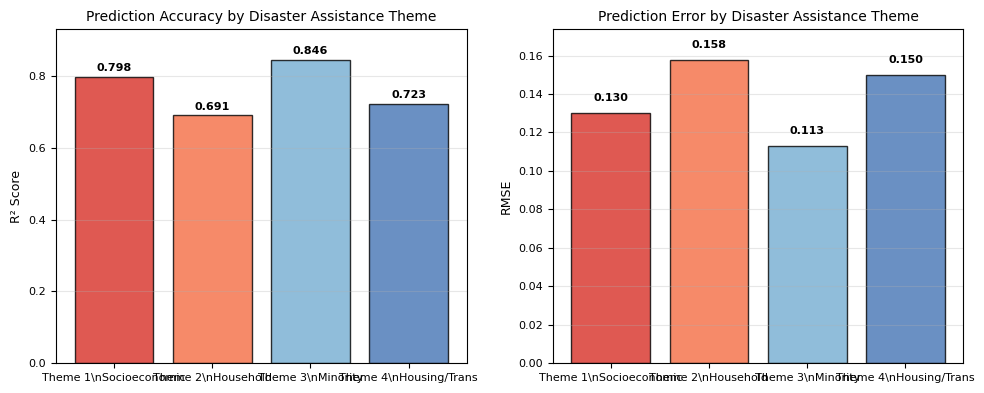

\nPer-Theme Performance Summary:
  RPL_THEME1: R²=0.7975, RMSE=0.1303
  RPL_THEME2: R²=0.6911, RMSE=0.1578
  RPL_THEME3: R²=0.8457, RMSE=0.1130
  RPL_THEME4: R²=0.7227, RMSE=0.1500


In [ ]:
#| label: fig-gat-per-theme-performance
#| fig-cap: "GAT model performance across four disaster assistance outcome dimensions. Left: R² scores showing predictive accuracy for each theme. Right: RMSE values showing absolute error magnitude. Higher R² and lower RMSE indicate better prediction of disaster assistance needs."

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

themes = per_target_metrics["target"].values
r2_scores = per_target_metrics["r2"].values
rmse_scores = per_target_metrics["rmse"].values

ax1 = axes[0]
bars1 = ax1.bar(range(len(themes)), r2_scores, color=["#d73027", "#f46d43", "#74add1", "#4575b4"], 
                edgecolor="black", alpha=0.8)
ax1.set_xticks(range(len(themes)))
ax1.set_xticklabels(["Theme 1\\nSocioeconomic", "Theme 2\\nHousehold", 
                     "Theme 3\\nMinority", "Theme 4\\nHousing/Trans"], 
                    fontsize=8, rotation=0)
ax1.set_ylabel("R² Score", fontsize=9)
ax1.set_title("Prediction Accuracy by Disaster Assistance Theme", fontsize=10)
ax1.set_ylim([0, max(r2_scores) * 1.1])
ax1.grid(alpha=0.3, axis="y")

for i, (bar, val) in enumerate(zip(bars1, r2_scores)):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f"{val:.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

ax2 = axes[1]
bars2 = ax2.bar(range(len(themes)), rmse_scores, color=["#d73027", "#f46d43", "#74add1", "#4575b4"],
                edgecolor="black", alpha=0.8)
ax2.set_xticks(range(len(themes)))
ax2.set_xticklabels(["Theme 1\\nSocioeconomic", "Theme 2\\nHousehold",
                     "Theme 3\\nMinority", "Theme 4\\nHousing/Trans"],
                    fontsize=8, rotation=0)
ax2.set_ylabel("RMSE", fontsize=9)
ax2.set_title("Prediction Error by Disaster Assistance Theme", fontsize=10)
ax2.set_ylim([0, max(rmse_scores) * 1.1])
ax2.grid(alpha=0.3, axis="y")

for i, (bar, val) in enumerate(zip(bars2, rmse_scores)):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{val:.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.show()

print("\\nPer-Theme Performance Summary:")
for i, theme in enumerate(themes):
    print(f"  {theme}: R²={r2_scores[i]:.4f}, RMSE={rmse_scores[i]:.4f}")

In [ ]:
#| output: false

torch.save(model.state_dict(), artifacts_dir / "gat_model.pt")

with open(artifacts_dir / "gat_config.json", "w") as f:
    json.dump(gat_config, f, indent=2)

gat_results = {
    "test_rmse": test_metrics["rmse"],
    "test_r2": test_metrics["r2"],
    "best_epoch": best_epoch,
    "best_val_loss": best_val_loss,
    "per_target": per_target_metrics.to_dict(orient="records"),
}

with open(artifacts_dir / "gat_results.json", "w") as f:
    json.dump(gat_results, f, indent=2)

print("save is good.")

save is good.
